In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.11.0+cpu
CUDA available: False


In [3]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded:", filename)

Saving synthetic_disaster_geospatial_FINAL.csv to synthetic_disaster_geospatial_FINAL.csv
Uploaded: synthetic_disaster_geospatial_FINAL.csv


In [4]:
import os

print("Files in /content:")

for f in os.listdir("/content"):
    print(f)

Files in /content:
.config
synthetic_disaster_geospatial_FINAL.csv
sample_data


In [5]:
import pandas as pd

DATASET_PATH = "/content/synthetic_disaster_geospatial_FINAL.csv"

df = pd.read_csv(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 10 rows:")
display(df.head(10))

DATASET LOADED SUCCESSFULLY
Shape: (16950, 20)

Columns:
['report_id', 'timestamp', 'latitude', 'longitude', 'disaster_type', 'report_type', 'urgency_score', 'people_affected', 'severity', 'resource_needed', 'simulation_zone', 'past_report_count_30min', 'past_report_count_60min', 'report_growth_30min', 'past_avg_urgency_30min', 'past_people_30min', 'future_report_count_30min', 'future_avg_urgency_30min', 'future_people_30min', 'risk_level_next_30min']

First 10 rows:


,report_id,timestamp,latitude,longitude,disaster_type,report_type,urgency_score,people_affected,severity,resource_needed,simulation_zone,past_report_count_30min,past_report_count_60min,report_growth_30min,past_avg_urgency_30min,past_people_30min,future_report_count_30min,future_avg_urgency_30min,future_people_30min,risk_level_next_30min
0,R000001,2026-08-19 00:00:00,18.511867,73.863400,Flood,Rising water,61,7,Medium,RESCUE_TEAM,Z01,0.0,0.0,0.0,0.0,0.0,73.0,64.469425,849.0,MEDIUM
1,R000039,2026-08-19 00:00:00,18.500481,73.804740,Flood,Blocked road,80,9,High,FOOD_WATER,Z02,0.0,0.0,0.0,0.0,0.0,68.0,67.595497,864.0,HIGH
2,R000002,2026-08-19 00:00:00,18.519196,73.855616,Flood,Medical emergency,96,42,Severe,FOOD_WATER,Z01,0.0,0.0,0.0,0.0,0.0,73.0,64.469425,849.0,MEDIUM
3,R000003,2026-08-19 00:00:00,18.521124,73.853753,Flood,Flooded house,74,9,High,RESCUE_TEAM,Z01,0.0,0.0,0.0,0.0,0.0,73.0,64.469425,849.0,MEDIUM
4,R000004,2026-08-19 00:00:00,18.518252,73.859852,Flood,Blocked road,82,4,High,MEDICAL,Z01,0.0,0.0,0.0,0.0,0.0,73.0,64.469425,849.0,MEDIUM
5,R000005,2026-08-19 00:00:00,18.517191,73.863171,Flood,Flooded house,78,8,High,FOOD_WATER,Z01,0.0,0.0,0.0,0.0,0.0,73.0,64.469425,849.0,MEDIUM
6,R000006,2026-08-19 00:00:00,18.518098,73.863187,Flood,Blocked road,52,8,Medium,MEDICAL,Z01,0.0,0.0,0.0,0.0,0.0,73.0,64.469425,849.0,MEDIUM
7,R000007,2026-08-19 00:00:00,18.518064,73.854505,Flood,Flooded house,73,9,High,FOOD_WATER,Z01,0.0,0.0,0.0,0.0,0.0,73.0,64.469425,849.0,MEDIUM
8,R000008,2026-08-19 00:00:00,18.516684,73.863633,Flood,Food/water shortage,78,7,High,BOAT,Z01,0.0,0.0,0.0,0.0,0.0,73.0,64.469425,849.0,MEDIUM
9,R000009,2026-08-19 00:00:00,18.531918,73.871824,Flood,Medical emergency,82,11,High,BOAT,Z01,0.0,0.0,0.0,0.0,0.0,73.0,64.469425,849.0,MEDIUM


In [6]:
print("=" * 60)
print("DATASET INSPECTION")
print("=" * 60)

print("\nShape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of unique values:")
print(df.nunique())

DATASET INSPECTION

Shape:
(16950, 20)

Data types:
report_id                     object
timestamp                     object
latitude                     float64
longitude                    float64
disaster_type                 object
report_type                   object
urgency_score                  int64
people_affected                int64
severity                      object
resource_needed               object
simulation_zone               object
past_report_count_30min      float64
past_report_count_60min      float64
report_growth_30min          float64
past_avg_urgency_30min       float64
past_people_30min            float64
future_report_count_30min    float64
future_avg_urgency_30min     float64
future_people_30min          float64
risk_level_next_30min         object
dtype: object

Missing values:
report_id                      0
timestamp                      0
latitude                       0
longitude                      0
disaster_type                  0
report_type 

In [7]:
print("=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)

target = "risk_level_next_30min"

print(df[target].value_counts(dropna=False))

print("\nPercentages:")
print(
    df[target]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)

TARGET DISTRIBUTION
risk_level_next_30min
MEDIUM      4179
HIGH        4174
LOW         4173
CRITICAL    4148
NaN          276
Name: count, dtype: int64

Percentages:
risk_level_next_30min
MEDIUM      24.65
HIGH        24.63
LOW         24.62
CRITICAL    24.47
NaN          1.63
Name: proportion, dtype: float64


In [8]:
import pandas as pd
import numpy as np

# Target
TARGET = "risk_level_next_30min"

# Remove rows where target is missing
data = df.dropna(subset=[TARGET]).copy()

# Remove future-information columns to prevent data leakage
future_columns = [
    "future_report_count_30min",
    "future_avg_urgency_30min",
    "future_people_30min"
]

# Columns that should not be used as predictive features
drop_columns = [
    "report_id",
    "timestamp",
    "disaster_type",       # only one unique value
    TARGET
] + future_columns

X = data.drop(columns=drop_columns)
y = data[TARGET]

print("Original dataset:", df.shape)
print("Usable dataset:", data.shape)
print("Features:", X.shape)
print("Target:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Original dataset: (16950, 20)
Usable dataset: (16674, 20)
Features: (16674, 13)
Target: (16674,)

Features:
['latitude', 'longitude', 'report_type', 'urgency_score', 'people_affected', 'severity', 'resource_needed', 'simulation_zone', 'past_report_count_30min', 'past_report_count_60min', 'report_growth_30min', 'past_avg_urgency_30min', 'past_people_30min']

Target distribution:
risk_level_next_30min
MEDIUM      4179
HIGH        4174
LOW         4173
CRITICAL    4148
Name: count, dtype: int64


In [9]:
# ============================================================
# STEP 6: CONVERT CATEGORICAL FEATURES
# ============================================================

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=False
)

print("\nFinal feature shape:", X.shape)

print("\nMissing values in features:")
print(X.isnull().sum().sum())

Categorical columns:
['report_type', 'severity', 'resource_needed', 'simulation_zone']

Final feature shape: (16674, 30)

Missing values in features:
0


In [10]:
# ============================================================
# STEP 7: TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTesting distribution:")
print(y_test.value_counts())

TRAIN / TEST SPLIT
Training samples: 13339
Testing samples: 3335

Training distribution:
risk_level_next_30min
MEDIUM      3343
HIGH        3339
LOW         3338
CRITICAL    3319
Name: count, dtype: int64

Testing distribution:
risk_level_next_30min
MEDIUM      836
HIGH        835
LOW         835
CRITICAL    829
Name: count, dtype: int64


In [11]:
# ============================================================
# STEP 8: TRAIN RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

print("=" * 60)
print("TRAINING RANDOM FOREST")
print("=" * 60)

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("\nTraining completed successfully!")

TRAINING RANDOM FOREST

Training completed successfully!


In [12]:
# ============================================================
# STEP 9: MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("=" * 60)
print("FINAL MODEL RESULTS")
print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

FINAL MODEL RESULTS
Accuracy : 0.9790
Precision: 0.9791
Recall   : 0.9790
F1 Score : 0.9790

Classification Report:
              precision    recall  f1-score   support

    CRITICAL       0.98      0.97      0.97       829
        HIGH       0.99      0.98      0.99       835
         LOW       0.99      0.99      0.99       835
      MEDIUM       0.96      0.98      0.97       836

    accuracy                           0.98      3335
   macro avg       0.98      0.98      0.98      3335
weighted avg       0.98      0.98      0.98      3335



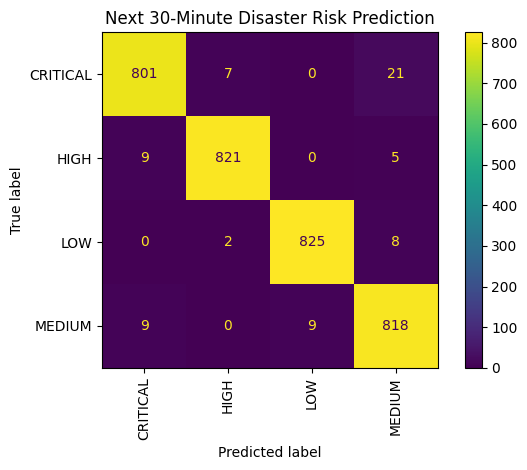

In [13]:
# ============================================================
# STEP 10: CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation="vertical"
)

plt.title("Next 30-Minute Disaster Risk Prediction")
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# STEP 11: FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("=" * 60)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 60)

display(importance.head(15))

TOP 15 IMPORTANT FEATURES


,Feature,Importance
5,past_report_count_60min,0.202741
4,past_report_count_30min,0.196369
8,past_people_30min,0.180157
7,past_avg_urgency_30min,0.108725
6,report_growth_30min,0.100390
0,latitude,0.050539
1,longitude,0.031844
24,simulation_zone_Z01,0.026680
28,simulation_zone_Z05,0.021129
25,simulation_zone_Z02,0.015490


In [15]:
# ============================================================
# STEP 12: SAVE TRAINED MODEL
# ============================================================

import joblib

MODEL_PATH = "/content/disaster_risk_random_forest.pkl"

joblib.dump(model, MODEL_PATH)

print("=" * 60)
print("MODEL SAVED")
print("=" * 60)
print("Location:", MODEL_PATH)

MODEL SAVED
Location: /content/disaster_risk_random_forest.pkl


In [16]:
# ============================================================
# STEP 13: SAVE TEST PREDICTIONS
# ============================================================

prediction_results = pd.DataFrame({
    "actual_risk": y_test.values,
    "predicted_risk": y_pred
})

PREDICTION_PATH = "/content/disaster_risk_predictions.csv"

prediction_results.to_csv(
    PREDICTION_PATH,
    index=False
)

print("=" * 60)
print("PREDICTIONS SAVED")
print("=" * 60)
print("Location:", PREDICTION_PATH)

display(prediction_results.head(20))

PREDICTIONS SAVED
Location: /content/disaster_risk_predictions.csv


,actual_risk,predicted_risk
0,HIGH,HIGH
1,CRITICAL,CRITICAL
2,CRITICAL,CRITICAL
3,LOW,LOW
4,MEDIUM,MEDIUM
5,MEDIUM,MEDIUM
6,LOW,LOW
7,HIGH,HIGH
8,LOW,LOW
9,LOW,LOW


In [17]:
# ============================================================
# STEP 14: SAVE MODEL METRICS
# ============================================================

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

METRICS_PATH = "/content/disaster_risk_metrics.csv"

metrics.to_csv(
    METRICS_PATH,
    index=False
)

print("=" * 60)
print("METRICS SAVED")
print("=" * 60)

display(metrics)

METRICS SAVED


,Metric,Score
0,Accuracy,0.979010
1,Precision,0.979117
2,Recall,0.979010
3,F1 Score,0.979030


In [18]:
from google.colab import files

files.download("/content/disaster_risk_random_forest.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:

files.download("/content/disaster_risk_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
files.download("/content/disaster_risk_metrics.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# ============================================================
# STEP 15: WEIGHTED RISK SCORE
# ============================================================

import numpy as np

risk_df = df.copy()

# Normalize important factors to 0-100
risk_df["urgency_norm"] = (
    risk_df["urgency_score"] /
    risk_df["urgency_score"].max()
) * 100

risk_df["people_norm"] = (
    risk_df["people_affected"] /
    risk_df["people_affected"].max()
) * 100

risk_df["growth_norm"] = (
    risk_df["report_growth_30min"] /
    risk_df["report_growth_30min"].max()
) * 100

risk_df["past_reports_norm"] = (
    risk_df["past_report_count_60min"] /
    risk_df["past_report_count_60min"].max()
) * 100

# Weighted risk score
risk_df["weighted_risk_score"] = (
    0.30 * risk_df["urgency_norm"] +
    0.30 * risk_df["people_norm"] +
    0.20 * risk_df["growth_norm"] +
    0.20 * risk_df["past_reports_norm"]
)

# Convert score into priority level
def assign_priority(score):
    if score >= 75:
        return "CRITICAL"
    elif score >= 50:
        return "HIGH"
    elif score >= 25:
        return "MEDIUM"
    else:
        return "LOW"

risk_df["weighted_risk_level"] = (
    risk_df["weighted_risk_score"]
    .apply(assign_priority)
)

print("=" * 60)
print("WEIGHTED RISK SCORE")
print("=" * 60)

display(
    risk_df[
        [
            "report_id",
            "urgency_score",
            "people_affected",
            "report_growth_30min",
            "past_report_count_60min",
            "weighted_risk_score",
            "weighted_risk_level"
        ]
    ].head(20)
)

WEIGHTED RISK SCORE


,report_id,urgency_score,people_affected,report_growth_30min,past_report_count_60min,weighted_risk_score,weighted_risk_level
0,R000001,61,7,0.0,0.0,23.072727,LOW
1,R000039,80,9,0.0,0.0,30.136364,MEDIUM
2,R000002,96,42,0.0,0.0,57.436364,HIGH
3,R000003,74,9,0.0,0.0,28.336364,MEDIUM
4,R000004,82,4,0.0,0.0,27.327273,MEDIUM
5,R000005,78,8,0.0,0.0,28.854545,MEDIUM
6,R000006,52,8,0.0,0.0,21.054545,LOW
7,R000007,73,9,0.0,0.0,28.036364,MEDIUM
8,R000008,78,7,0.0,0.0,28.172727,MEDIUM
9,R000009,82,11,0.0,0.0,32.100000,MEDIUM


In [22]:
# ============================================================
# STEP 16: DBSCAN DISASTER HOTSPOT CLUSTERING
# ============================================================

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Select geographic coordinates
coordinates = risk_df[
    ["latitude", "longitude"]
].copy()

# Scale coordinates
scaled_coordinates = StandardScaler().fit_transform(
    coordinates
)

# DBSCAN clustering
dbscan = DBSCAN(
    eps=0.20,
    min_samples=5
)

risk_df["cluster_id"] = dbscan.fit_predict(
    scaled_coordinates
)

# Number of clusters
cluster_labels = set(risk_df["cluster_id"])

number_of_clusters = len(cluster_labels - {-1})

noise_points = (
    risk_df["cluster_id"] == -1
).sum()

print("=" * 60)
print("DBSCAN DISASTER HOTSPOT CLUSTERING")
print("=" * 60)

print("Number of clusters:", number_of_clusters)
print("Noise points:", noise_points)

print("\nCluster distribution:")

display(
    risk_df["cluster_id"]
    .value_counts()
    .head(15)
)

DBSCAN DISASTER HOTSPOT CLUSTERING
Number of clusters: 6
Noise points: 0

Cluster distribution:


,count
cluster_id,
0,5147
1,4140
4,2846
2,2440
3,1462
5,915


In [23]:
!pip -q install sentence-transformers

In [24]:
# ============================================================
# STEP 17: SENTENCE EMBEDDINGS + COSINE SIMILARITY
# ============================================================

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("Loading sentence embedding model...")

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Embedding model loaded successfully!")

reports = [
    "Road is blocked near the bridge due to flooding",
    "Flooding has blocked the road near the bridge",
    "Fire reported at the industrial area",
    "Industrial area fire emergency reported",
    "Heavy rain reported in the city"
]

# Convert reports into sentence embeddings
embeddings = embedding_model.encode(
    reports,
    convert_to_numpy=True
)

# Calculate cosine similarity
similarity_matrix = cosine_similarity(
    embeddings
)

print("=" * 60)
print("DUPLICATE REPORT DETECTION")
print("=" * 60)

for i in range(len(reports)):
    for j in range(i + 1, len(reports)):

        similarity = similarity_matrix[i][j]

        print(
            f"\nReport {i+1} vs Report {j+1}"
        )

        print(
            f"Similarity: {similarity:.4f}"
        )

        if similarity >= 0.75:
            print("→ POSSIBLE DUPLICATE")
        else:
            print("→ DIFFERENT REPORT")

Loading sentence embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully!
DUPLICATE REPORT DETECTION

Report 1 vs Report 2
Similarity: 0.9756
→ POSSIBLE DUPLICATE

Report 1 vs Report 3
Similarity: 0.0776
→ DIFFERENT REPORT

Report 1 vs Report 4
Similarity: 0.1198
→ DIFFERENT REPORT

Report 1 vs Report 5
Similarity: 0.3102
→ DIFFERENT REPORT

Report 2 vs Report 3
Similarity: 0.0961
→ DIFFERENT REPORT

Report 2 vs Report 4
Similarity: 0.1375
→ DIFFERENT REPORT

Report 2 vs Report 5
Similarity: 0.3479
→ DIFFERENT REPORT

Report 3 vs Report 4
Similarity: 0.8766
→ POSSIBLE DUPLICATE

Report 3 vs Report 5
Similarity: 0.2693
→ DIFFERENT REPORT

Report 4 vs Report 5
Similarity: 0.2844
→ DIFFERENT REPORT


In [25]:
# ============================================================
# STEP 18: EMERGENCY PRIORITY QUEUE
# ============================================================

import heapq

priority_map = {
    "CRITICAL": 1,
    "HIGH": 2,
    "MEDIUM": 3,
    "LOW": 4
}

priority_queue = []

# Add reports to priority queue
for _, row in risk_df.head(100).iterrows():

    risk_level = row["weighted_risk_level"]
    priority = priority_map[risk_level]

    heapq.heappush(
        priority_queue,
        (
            priority,
            -row["weighted_risk_score"],
            row["report_id"]
        )
    )

print("=" * 60)
print("EMERGENCY PRIORITY QUEUE")
print("=" * 60)

count = 0

while priority_queue and count < 10:

    priority, negative_score, report_id = heapq.heappop(
        priority_queue
    )

    score = -negative_score

    print(
        f"{count + 1}. "
        f"Report={report_id} | "
        f"Priority={priority} | "
        f"Risk Score={score:.2f}"
    )

    count += 1

EMERGENCY PRIORITY QUEUE
1. Report=R000106 | Priority=2 | Risk Score=58.91
2. Report=R000083 | Priority=2 | Risk Score=58.52
3. Report=R000002 | Priority=2 | Risk Score=57.44
4. Report=R000075 | Priority=2 | Risk Score=56.97
5. Report=R000068 | Priority=2 | Risk Score=53.37
6. Report=R000084 | Priority=2 | Risk Score=51.18
7. Report=R000078 | Priority=2 | Risk Score=51.03
8. Report=R000090 | Priority=2 | Risk Score=50.20
9. Report=R000064 | Priority=3 | Risk Score=48.35
10. Report=R000010 | Priority=3 | Risk Score=47.81


In [26]:
# ============================================================
# STEP 19: GREEDY RESOURCE ALLOCATION
# ============================================================

# Available emergency resources
resources = {
    "ambulance": 3,
    "fire_truck": 2,
    "rescue_team": 2
}

allocations = []

# Sort reports by highest risk score first
sorted_reports = risk_df.sort_values(
    by="weighted_risk_score",
    ascending=False
)

# Greedy allocation:
# Give the best available resource to the highest-risk report
for _, row in sorted_reports.iterrows():

    report_type = str(row["report_type"]).lower()

    # Determine required resource
    if "medical" in report_type or "injury" in report_type:
        resource = "ambulance"

    elif "fire" in report_type:
        resource = "fire_truck"

    else:
        resource = "rescue_team"

    # Allocate if resource is available
    if resources[resource] > 0:

        resources[resource] -= 1

        allocations.append({
            "report_id": row["report_id"],
            "risk_level": row["weighted_risk_level"],
            "risk_score": round(
                row["weighted_risk_score"], 2
            ),
            "allocated_resource": resource
        })

# Convert results to DataFrame
allocation_df = pd.DataFrame(allocations)

print("=" * 60)
print("GREEDY RESOURCE ALLOCATION")
print("=" * 60)

display(allocation_df)

print("\nRemaining resources:")
print(resources)

GREEDY RESOURCE ALLOCATION


,report_id,risk_level,risk_score,allocated_resource
0,R009693,CRITICAL,90.35,rescue_team
1,R009653,CRITICAL,89.31,rescue_team
2,R010610,CRITICAL,87.27,ambulance
3,R006229,CRITICAL,87.00,ambulance
4,R009649,CRITICAL,83.17,ambulance



Remaining resources:
{'ambulance': 0, 'fire_truck': 2, 'rescue_team': 0}


In [27]:
# ============================================================
# FINAL END-TO-END DISASTER RESPONSE DEMO
# ============================================================

final_demo = risk_df[
    [
        "report_id",
        "latitude",
        "longitude",
        "weighted_risk_score",
        "weighted_risk_level",
        "cluster_id"
    ]
].copy()

# Sort by emergency risk
final_demo = final_demo.sort_values(
    "weighted_risk_score",
    ascending=False
)

# Add recommended action
def recommend_action(level):
    if level == "CRITICAL":
        return "Immediate rescue / medical response"
    elif level == "HIGH":
        return "Rapid emergency coordination"
    elif level == "MEDIUM":
        return "Coordinate relief resources"
    else:
        return "Monitor situation"

final_demo["recommended_action"] = (
    final_demo["weighted_risk_level"]
    .apply(recommend_action)
)

print("=" * 80)
print("FINAL DISASTER RESPONSE AI OUTPUT")
print("=" * 80)

display(final_demo.head(20))

FINAL DISASTER RESPONSE AI OUTPUT


,report_id,latitude,longitude,weighted_risk_score,weighted_risk_level,cluster_id,recommended_action
9696,R009693,18.522152,73.861949,90.346853,CRITICAL,0,Immediate rescue / medical response
9660,R009653,18.519332,73.852368,89.310490,CRITICAL,0,Immediate rescue / medical response
9676,R009679,18.522080,73.847687,87.865035,CRITICAL,0,Immediate rescue / medical response
10606,R010610,18.505408,73.806874,87.272261,CRITICAL,1,Immediate rescue / medical response
6228,R006229,18.525364,73.853371,86.998368,CRITICAL,0,Immediate rescue / medical response
6088,R006092,18.523059,73.858079,85.917189,CRITICAL,0,Immediate rescue / medical response
8609,R008612,18.504485,73.805346,84.672910,CRITICAL,1,Immediate rescue / medical response
6243,R006236,18.517512,73.872696,84.598368,CRITICAL,0,Immediate rescue / medical response
9527,R009509,18.519846,73.858820,84.446509,CRITICAL,0,Immediate rescue / medical response
10600,R010618,18.508320,73.804723,84.081352,CRITICAL,1,Immediate rescue / medical response


In [30]:
import os

print("Files in /content:")

for f in os.listdir("/content"):
    print(f)

Files in /content:
.config
disaster_risk_random_forest.pkl
disaster_risk_predictions.csv
synthetic_disaster_geospatial_FINAL.csv
disaster_risk_metrics.csv
sample_data


In [31]:
# ============================================================
# RECREATE FINAL RESULTS FILE
# ============================================================

final_demo = risk_df[
    [
        "report_id",
        "latitude",
        "longitude",
        "weighted_risk_score",
        "weighted_risk_level",
        "cluster_id"
    ]
].copy()

final_demo = final_demo.sort_values(
    "weighted_risk_score",
    ascending=False
)

def recommend_action(level):
    if level == "CRITICAL":
        return "Immediate rescue / medical response"
    elif level == "HIGH":
        return "Rapid emergency coordination"
    elif level == "MEDIUM":
        return "Coordinate relief resources"
    else:
        return "Monitor situation"

final_demo["recommended_action"] = (
    final_demo["weighted_risk_level"]
    .apply(recommend_action)
)

FINAL_PATH = "/content/final_disaster_response_results.csv"

final_demo.to_csv(
    FINAL_PATH,
    index=False
)

print("=" * 60)
print("FINAL RESULTS SAVED SUCCESSFULLY")
print("=" * 60)
print("Location:", FINAL_PATH)
print("Rows:", len(final_demo))

display(final_demo.head(20))

FINAL RESULTS SAVED SUCCESSFULLY
Location: /content/final_disaster_response_results.csv
Rows: 16950


,report_id,latitude,longitude,weighted_risk_score,weighted_risk_level,cluster_id,recommended_action
9696,R009693,18.522152,73.861949,90.346853,CRITICAL,0,Immediate rescue / medical response
9660,R009653,18.519332,73.852368,89.310490,CRITICAL,0,Immediate rescue / medical response
9676,R009679,18.522080,73.847687,87.865035,CRITICAL,0,Immediate rescue / medical response
10606,R010610,18.505408,73.806874,87.272261,CRITICAL,1,Immediate rescue / medical response
6228,R006229,18.525364,73.853371,86.998368,CRITICAL,0,Immediate rescue / medical response
6088,R006092,18.523059,73.858079,85.917189,CRITICAL,0,Immediate rescue / medical response
8609,R008612,18.504485,73.805346,84.672910,CRITICAL,1,Immediate rescue / medical response
6243,R006236,18.517512,73.872696,84.598368,CRITICAL,0,Immediate rescue / medical response
9527,R009509,18.519846,73.858820,84.446509,CRITICAL,0,Immediate rescue / medical response
10600,R010618,18.508320,73.804723,84.081352,CRITICAL,1,Immediate rescue / medical response


In [32]:
from google.colab import files

files.download(
    "/content/final_disaster_response_results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>